In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
from apps.onpe.schemas import ConsultaElectoral, Eleccion
from typing import Literal
from apps.onpe.client import get_resultados_onpe, cookies, headers
from apps.onpe.enums import UbigeoNivel1, UbigeoNivel2, UbigeoNivel3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
import math
import requests

In [76]:
count = 0

def procesar_un_ubigeo(ubigeo3):
    global count
    print(f"{count=}")
    count = count + 1
    # Aquí mueves TODO el contenido que tenías dentro de tu loop actual
    # incluyendo los try/except y las peticiones get_resultados_onpe
    try:
        consulta_electoral = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL, ubigeo_3=ubigeo3)

        data_detalle = get_resultados_onpe(consulta_electoral, mode='detalle')['data']
        data_participacion = get_resultados_onpe(consulta_electoral, mode="participacion")['data']

        actas_contabilizadas_porcentaje = data_participacion['porcentajeAsistentes'] + data_participacion['porcentajeAusentes']

        if actas_contabilizadas_porcentaje <= 10:
            print(f"Ubigeo {ubigeo3.name}: No se han contabilizado actas aún. Proyectando resultados...")
            total_actas = data_participacion['totalElectoresHabiles']

            # Calcular segun ubigeo nivel 2
            ubigeo_nivel_2 = ubigeo3.nivel2
            consulta_ubigeo_nivel_2 = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL, ubigeo_2=ubigeo_nivel_2)
            nivel_2_participacion = get_resultados_onpe(consulta_ubigeo_nivel_2, mode='participacion')['data']
            nivel_2_detalle = get_resultados_onpe(consulta_ubigeo_nivel_2, mode='detalle')['data']

            nivel_2_actas_porcentaje = nivel_2_participacion['porcentajeAsistentes'] + nivel_2_participacion['porcentajeAusentes']

            if nivel_2_actas_porcentaje <= 10:
                print(f"Ubigeo {ubigeo_nivel_2.name}: No se han contabilizado actas aún en el nivel2. Proyectando resultados...")
                # Calcular segun ubigeo nivel 1
                ubigeo_nivel_1 = ubigeo_nivel_2.nivel1
                consulta_ubigeo_nivel_1 = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL, ubigeo=ubigeo_nivel_1)
                nivel_1_participacion = get_resultados_onpe(consulta_ubigeo_nivel_1, mode='participacion')['data']
                nivel_1_detalle = get_resultados_onpe(consulta_ubigeo_nivel_1, mode='detalle')['data']

                nivel_1_actas_porcentaje = nivel_1_participacion['porcentajeAsistentes'] + nivel_1_participacion['porcentajeAusentes']
                nivel_1_jp_votos = next(d['totalVotosValidos'] for d in nivel_1_detalle if d['nombreAgrupacionPolitica'] == 'JUNTOS POR EL PERÚ')
                nivel_1_porky_votos = next(d['totalVotosValidos'] for d in nivel_1_detalle if d['nombreAgrupacionPolitica'] == 'RENOVACIÓN POPULAR')

                nivel_1_jp_votos_proyectados = nivel_1_jp_votos * 100 / nivel_1_actas_porcentaje
                nivel_1_porky_votos_proyectados = nivel_1_porky_votos * 100 / nivel_1_actas_porcentaje

                total_actas_nivel_1 = nivel_1_participacion['totalElectoresHabiles']

                nivel_2_jp_votos_proyectados = nivel_1_jp_votos_proyectados * total_actas / total_actas_nivel_1
                nivel_2_porky_votos_proyectados = nivel_1_porky_votos_proyectados * total_actas / total_actas_nivel_1

                jp_data = {
                    'nombreAgrupacionPolitica': 'JUNTOS POR EL PERÚ',
                    'ubigeo1': ubigeo_nivel_1.name,
                    'ubigeo2': ubigeo_nivel_2.name,
                    'ubigeo3': ubigeo3.name,
                    'actualVotosValidos': nivel_2_jp_votos_proyectados,
                    'proyeccionVotosValidos': nivel_2_jp_votos_proyectados
                }

                porky_data = {
                    'nombreAgrupacionPolitica': 'RENOVACIÓN POPULAR',
                    'ubigeo1': ubigeo_nivel_1.name,
                    'ubigeo2': ubigeo_nivel_2.name,
                    'ubigeo3': ubigeo3.name,
                    'actualVotosValidos': nivel_2_porky_votos_proyectados,
                    'proyeccionVotosValidos': nivel_2_porky_votos_proyectados
                }
                return [jp_data, porky_data]
            
            nivel_2_jp_votos = next(d['totalVotosValidos'] for d in nivel_2_detalle if d['nombreAgrupacionPolitica'] == 'JUNTOS POR EL PERÚ')
            nivel_2_porky_votos = next(d['totalVotosValidos'] for d in nivel_2_detalle if d['nombreAgrupacionPolitica'] == 'RENOVACIÓN POPULAR')

            nivel_2_jp_votos_proyectados = nivel_2_jp_votos * 100 / nivel_2_actas_porcentaje
            nivel_2_porky_votos_proyectados = nivel_2_porky_votos * 100 / nivel_2_actas_porcentaje

            total_actas_nivel_2 = nivel_2_participacion['totalElectoresHabiles']

            nivel_2_jp_votos_proyectados = nivel_2_jp_votos_proyectados * total_actas / total_actas_nivel_2
            nivel_2_porky_votos_proyectados = nivel_2_porky_votos_proyectados * total_actas / total_actas_nivel_2

            jp_data = {
                'nombreAgrupacionPolitica': 'JUNTOS POR EL PERÚ',
                'ubigeo1': ubigeo_nivel_2.nivel1.name,
                'ubigeo2': ubigeo_nivel_2.name,
                'ubigeo3': ubigeo3.name,
                'actualVotosValidos': nivel_2_jp_votos_proyectados,
                'proyeccionVotosValidos': nivel_2_jp_votos_proyectados
            }

            porky_data = {
                'nombreAgrupacionPolitica': 'RENOVACIÓN POPULAR',
                'ubigeo1': ubigeo_nivel_2.nivel1.name,
                'ubigeo2': ubigeo_nivel_2.name,
                'ubigeo3': ubigeo3.name,
                'actualVotosValidos': nivel_2_porky_votos_proyectados,
                'proyeccionVotosValidos': nivel_2_porky_votos_proyectados
            }
            return [jp_data, porky_data]

        return [{
            'nombreAgrupacionPolitica': data['nombreAgrupacionPolitica'],
            'ubigeo1': consulta_electoral.ubigeo.name,
            'ubigeo2': consulta_electoral.ubigeo_2.name,
            'ubigeo3': consulta_electoral.ubigeo_3.name,
            'actualVotosValidos': data['totalVotosValidos'],
            'proyeccionVotosValidos': data['totalVotosValidos'] * 100 / actas_contabilizadas_porcentaje
        } for data in data_detalle]
    except Exception as e:
        print(f"Error en {ubigeo3.name}: {e}")
        return []

In [102]:
def plot_proyeccion():
    count = 0
    all_data = []
    with ThreadPoolExecutor(max_workers=20) as executor:
        # Mapeamos la función a la lista de ubigeos
        resultados = list(executor.map(procesar_un_ubigeo, UbigeoNivel3))

    all_data = [item for sublist in resultados for item in sublist]
    df_proyeccion = pd.DataFrame(all_data)
    df_proyeccion['proyeccionVotosValidos']= df_proyeccion['proyeccionVotosValidos'].astype(int)
    df_proyeccion['actualVotosValidos']= df_proyeccion['actualVotosValidos'].astype(int)

    df_sum = df_proyeccion.sum(numeric_only=True)
    votos_proyectados = df_sum['proyeccionVotosValidos'] - df_sum['actualVotosValidos']
    turnout = df_sum['proyeccionVotosValidos'] / 27_325_432 * 100

    df_final = df_proyeccion.groupby('nombreAgrupacionPolitica').sum(numeric_only=True).sort_values('proyeccionVotosValidos', ascending=False)
    # df_final.drop(index=['VOTOS EN BLANCO', 'VOTOS NULOS'], inplace=True)
    df_final['porcentaje_final'] = df_final['proyeccionVotosValidos'] / df_final['proyeccionVotosValidos'].sum() * 100

    consulta_total = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL)
    resumen_total = get_resultados_onpe(consulta_total, mode="resumen")['data']
    actas_contabilizadas_total = resumen_total['actasContabilizadas']

    # 1. Configuración estética
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 10)) # Aumentamos un poco el ancho para que quepan las etiquetas

    # 2. Dibujamos la barra de PROYECCIÓN (Fondo - el total esperado)
    ax = sns.barplot(
        data=df_final,
        x='proyeccionVotosValidos',
        y='nombreAgrupacionPolitica',
        color='#A2D2FF',  # Azul claro
        label='Crecimiento Proyectado'
    )

    # 3. Dibujamos la barra de VOTOS ACTUALES (Encima)
    sns.barplot(
        data=df_final,
        x='actualVotosValidos',
        y='nombreAgrupacionPolitica',
        color='#00308F',  # Azul oscuro
        label='Votos Actuales'
    )

    # 4. Personalización de etiquetas y títulos
    plt.title('Votos Actuales vs. Proyección Final por Partido', fontsize=18, fontweight='bold', pad=25)
    plt.xlabel('Cantidad de Votos', fontsize=13)
    plt.ylabel('Agrupación Política', fontsize=13)
    plt.legend(loc='lower right', frameon=True)

    # 5. Añadir el texto: "Votos Totales (Porcentaje%)"
    # Usamos f-strings para formatear los números con comas como separadores de miles
    for i, row in enumerate(df_final.itertuples()):
        votos_totales = getattr(row, 'proyeccionVotosValidos')
        porcentaje = getattr(row, 'porcentaje_final')
        
        label_text = f'{votos_totales:,.0f} ({porcentaje:.2f}%)'
        
        plt.text(
            votos_totales + (df_final['proyeccionVotosValidos'].max() * 0.01), # Un pequeño margen a la derecha
            i, 
            label_text, 
            va='center', 
            fontsize=10, 
            fontweight='bold',
            color='#333333'
        )

    plt.text(-0.5, 1.03, f"Datos obtenidos de ONPE API | Actas contabilizadas: {actas_contabilizadas_total}% | Votos proyectados: {votos_proyectados:,.0f} | Turnout proyectado: {turnout:.2f}%",
            transform=ax.transAxes, # Usar coordenadas de ejes para que no se mueva
            ha='center', va='top', 
            fontsize=10, 
            color='black',
            fontweight='bold')
    
    # Ajustar los límites del eje X para que las etiquetas no se corten
    plt.xlim(0, df_final['proyeccionVotosValidos'].max() * 1.25)

    plt.tight_layout()
    plt.show()

    return df_proyeccion, df_final

In [ ]:
df_pro, df_f = plot_proyeccion()

count=29428
count=29429
count=29430
count=29431
count=29432
count=29433
count=29434
count=29435
count=29436
count=29437
count=29438
count=29439
count=29440
count=29441
count=29442
count=29443
count=29444
count=29445
count=29446
count=29447
count=29448
count=29449
count=29450
count=29451
count=29452
count=29453
count=29454
count=29455
count=29456
count=29457
count=29458
count=29459
count=29460
count=29461
count=29462
count=29463
count=29464
count=29465
count=29466
count=29467
count=29468
count=29469
count=29470
count=29471
count=29472
count=29473
count=29474
count=29475
count=29476
count=29477
count=29478
count=29479
count=29480
count=29481
count=29482
count=29483
count=29484
count=29485
count=29486
count=29487
count=29488
count=29489
count=29490
count=29491
count=29492
count=29493
count=29494
count=29495
count=29496
count=29497
count=29498
count=29499
count=29500
count=29501
count=29502
count=29503
count=29504
count=29505
count=29506
count=29507
count=29508
count=29509
count=29510
coun

count=10510
count=10511
count=10512
count=10513
count=10514
count=10515
count=10516
count=10517
count=10518
count=10519
count=10520
count=10521
count=10522
count=10523
count=10524
count=10525
count=10526
count=10527
count=10528
count=10529
count=10530
count=10531
count=10532
count=10533
count=10534
count=10535
count=10536
count=10537
count=10538
count=10539
count=10540
count=10541
count=10542
count=10543
count=10544
count=10545
count=10546
count=10547
count=10548
count=10549
count=10550
count=10551
count=10552
count=10553
count=10554
count=10555
count=10556
count=10557
count=10558
count=10559
count=10560
count=10561
count=10562
count=10563
count=10564
count=10565
count=10566
count=10567
count=10568
count=10569
count=10570
count=10571
count=10572
count=10573
count=10574
count=10575
count=10576
count=10577
count=10578
count=10579
count=10580
count=10581
count=10582
count=10583
count=10584
count=10585
count=10586
count=10587
count=10588
count=10589
count=10590
count=10591
count=10592
coun

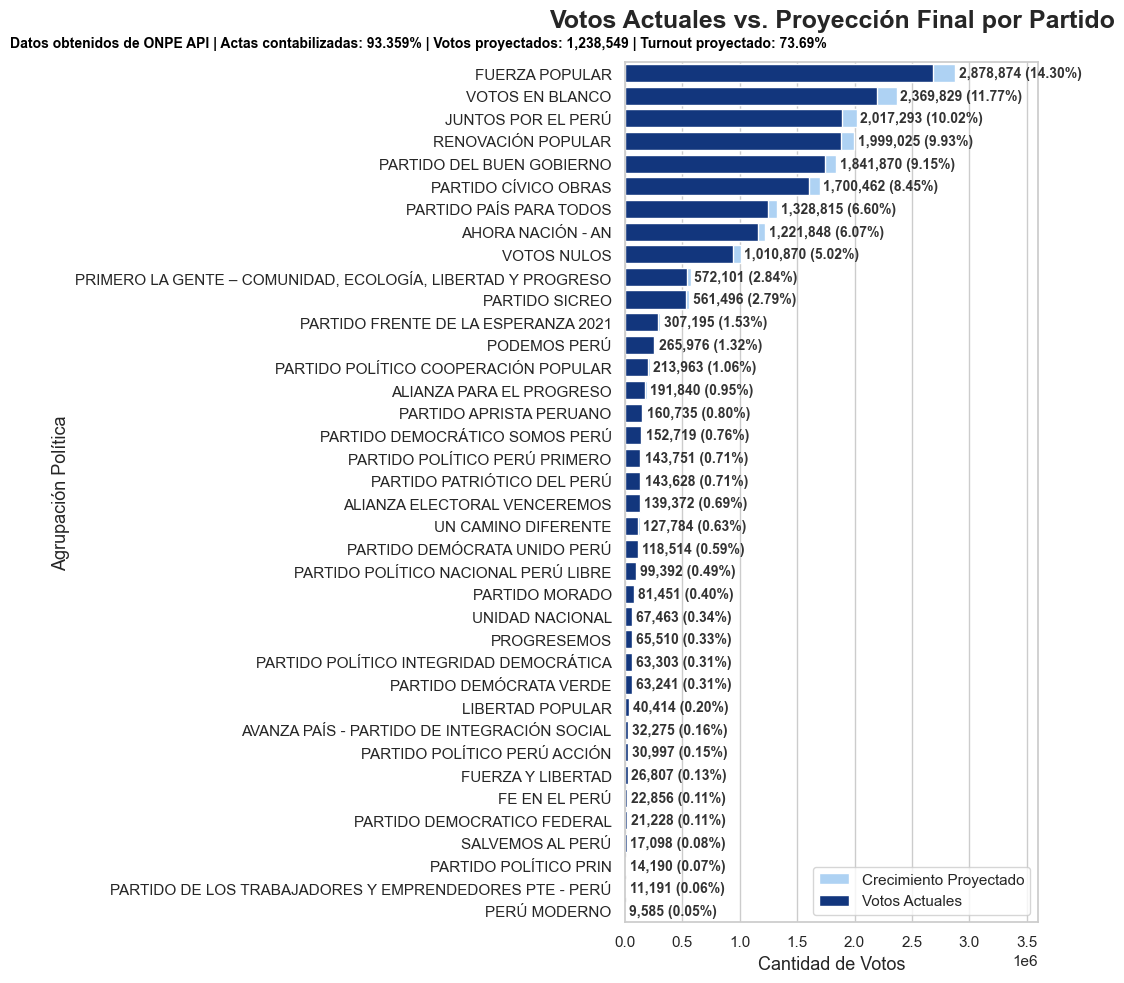

In [106]:
df_pro, df_f = plot_proyeccion()

count=8408count=8408

count=8410
count=8411
count=8412
count=8413
count=8414
count=8415
count=8416
count=8417
count=8418
count=8419
count=8420
count=8421
count=8422
count=8423
count=8424
count=8425
count=8426
count=8427
count=8428
count=8429
count=8430
count=8431
count=8432
count=8433
count=8434
count=8435
count=8436
count=8437
count=8438
count=8439
count=8440
count=8441
count=8442
count=8443
count=8444
count=8445
count=8446
count=8447
count=8448
count=8449
count=8450
count=8451
count=8452
count=8453
count=8454
count=8455
count=8456
count=8457
count=8458
count=8459
count=8460
count=8461
count=8462
count=8463
count=8464
count=8465
count=8466
count=8467
count=8468
count=8469
count=8470
count=8471
count=8472
count=8473
count=8474
count=8475
count=8476
count=8477
count=8478
count=8479
count=8480
count=8481
count=8482
count=8483
count=8484
count=8485
count=8486
count=8487
count=8488
count=8489
count=8490
count=8491
count=8492
count=8493
count=8494
count=8495
count=8496
count=8497
count=8498

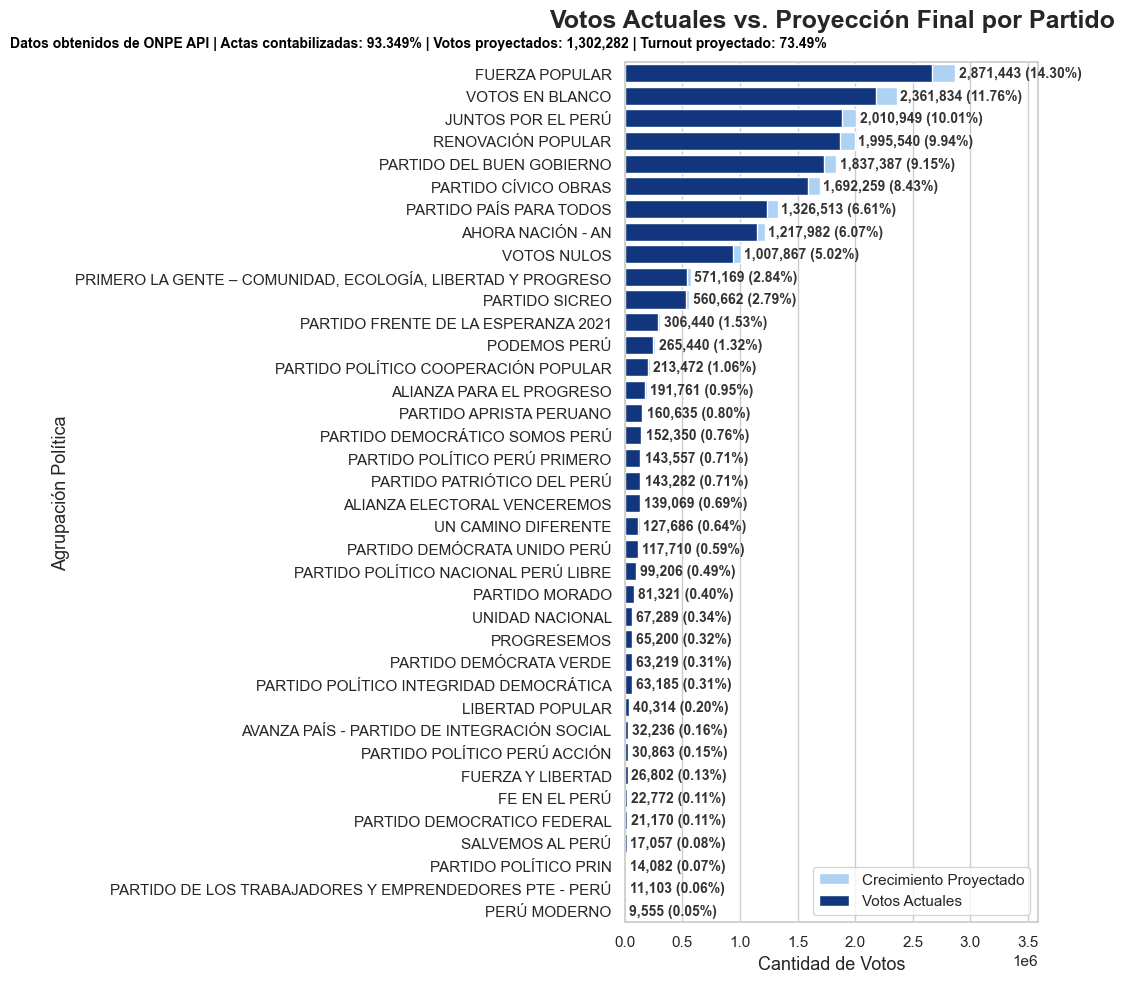

In [105]:
df_pro, df_f = plot_proyeccion()

count=2104
count=2105
count=2106
count=2107
count=2108
count=2109
count=2110
count=2111
count=2112
count=2113
count=2114
count=2115
count=2116
count=2117
count=2118
count=2119
count=2120
count=2121
count=2122
count=2123
count=2124
count=2125
count=2126
count=2127
count=2128
count=2129
count=2130
count=2131
count=2132
count=2133
count=2134
count=2135
count=2136
count=2137
count=2138
count=2139
count=2140
count=2141
count=2142
count=2143
count=2144
count=2145
count=2146
count=2147
count=2148
count=2149
count=2150
count=2151
count=2152
count=2153
count=2154
count=2155
count=2156
count=2157
count=2158
count=2159
count=2160
count=2161
count=2162
count=2163
count=2164
count=2165
count=2166
count=2167
count=2168
count=2169
count=2170
count=2171
count=2172
count=2173
count=2174
count=2175
count=2176
count=2177
count=2178
count=2179
count=2180
count=2181
count=2182
count=2183
count=2184
count=2185
count=2186
count=2187
count=2188
count=2189
count=2190
count=2191
count=2192
count=2193
count=2194

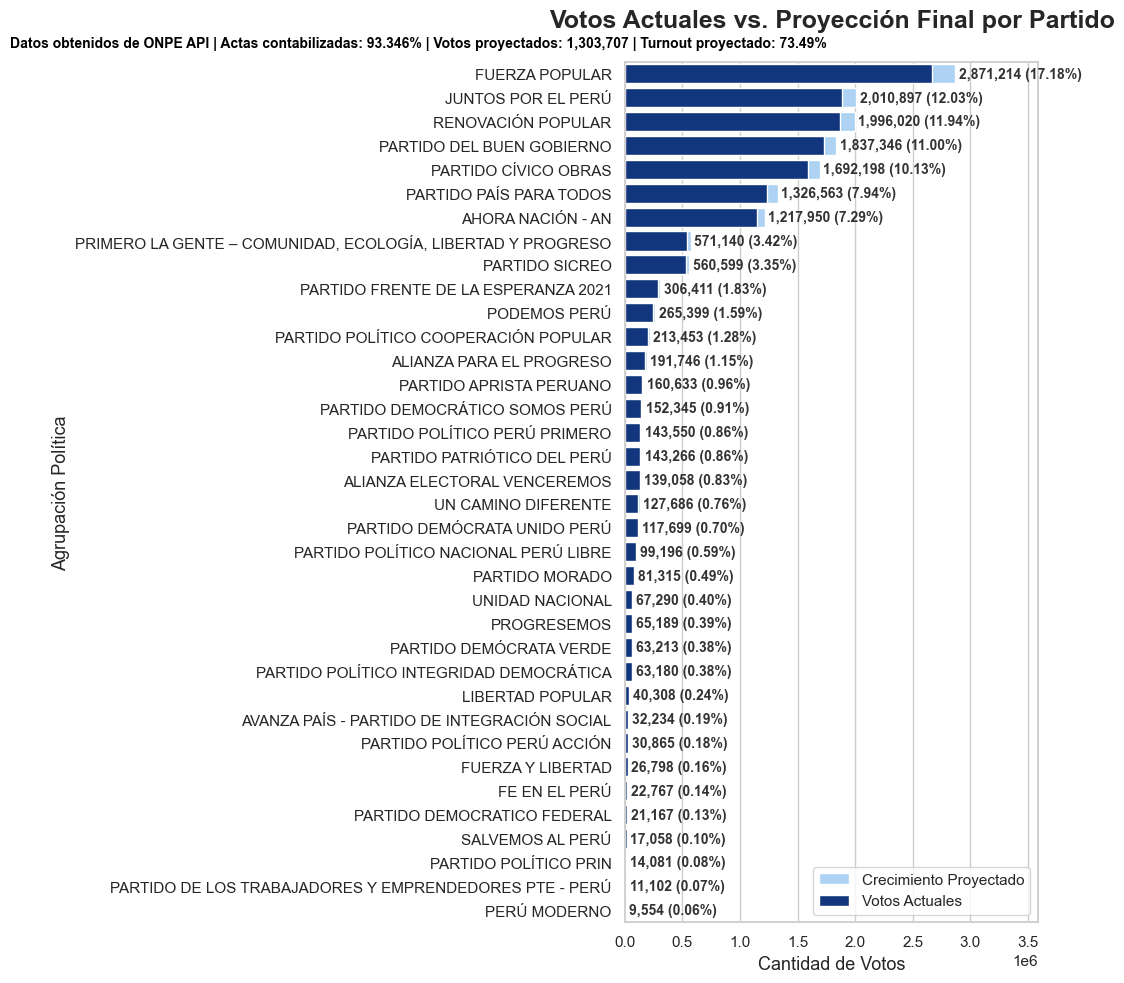

In [67]:
df_pro, df_f = plot_proyeccion()

In [97]:
df_pro['diferencia'] = df_pro['proyeccionVotosValidos'] - df_pro['actualVotosValidos']
df_pro['porcentaje_diferencia'] = df_pro['diferencia'] / df_pro['actualVotosValidos'] * 100

In [98]:
df_faltan = df_pro[(df_pro['porcentaje_diferencia'] > 0) & (df_pro['porcentaje_diferencia'] > 0) & (df_pro['nombreAgrupacionPolitica'].isin(['RENOVACIÓN POPULAR']))]

In [101]:
15_000 / df_faltan['diferencia'].sum() * 100

np.float64(11.671426014830493)

In [94]:
14_000 / df_faltan['diferencia'].sum() * 100

np.float64(5.503836960623977)

In [92]:
df_faltan['diferencia'].sum()

np.int64(254368)

count=33632
count=33633
count=33634
count=33635
count=33636
count=33637
count=33638
count=33639
count=33640
count=33641
count=33642
count=33643
count=33644
count=33645
count=33646
count=33647
count=33648
count=33649
count=33650
count=33651
count=33652
count=33653
count=33654
count=33655
count=33656
count=33657
count=33658
count=33659
count=33660
count=33661
count=33662
count=33663
count=33664
count=33665
count=33666
count=33667
count=33668
count=33669
count=33670
count=33671
count=33672
count=33673
count=33674
count=33675
count=33676
count=33677
count=33678
count=33679
count=33680
count=33681
count=33682
count=33683
count=33684
count=33685
count=33686
count=33687
count=33688
count=33689
count=33690
count=33691
count=33692
count=33693
count=33694
count=33695
count=33696
count=33697
count=33698
count=33699
count=33700
count=33701
count=33702
count=33703
count=33704
count=33705
count=33706
count=33707
count=33708
count=33709
count=33710
count=33711
count=33712
count=33713
count=33714
coun

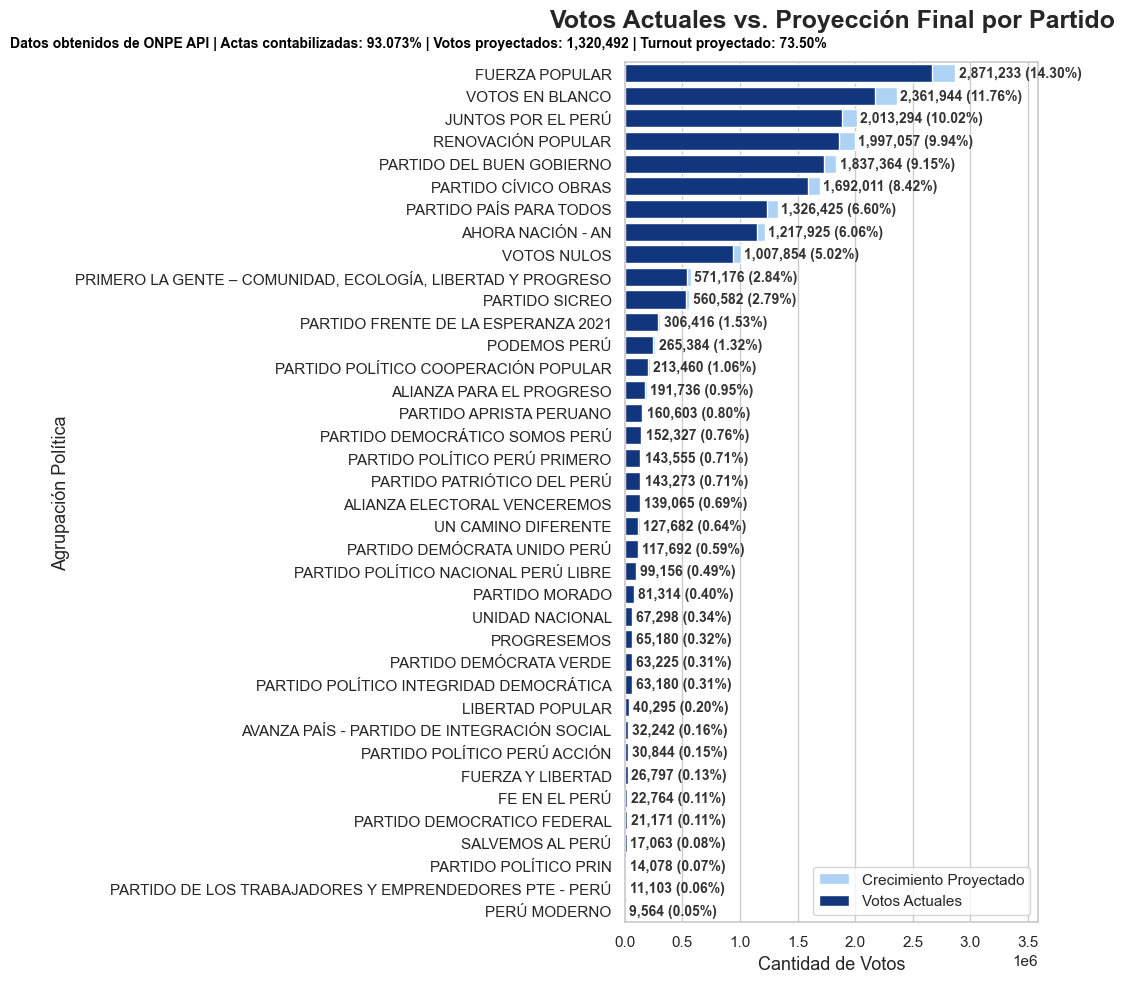

In [34]:
plot_proyeccion()

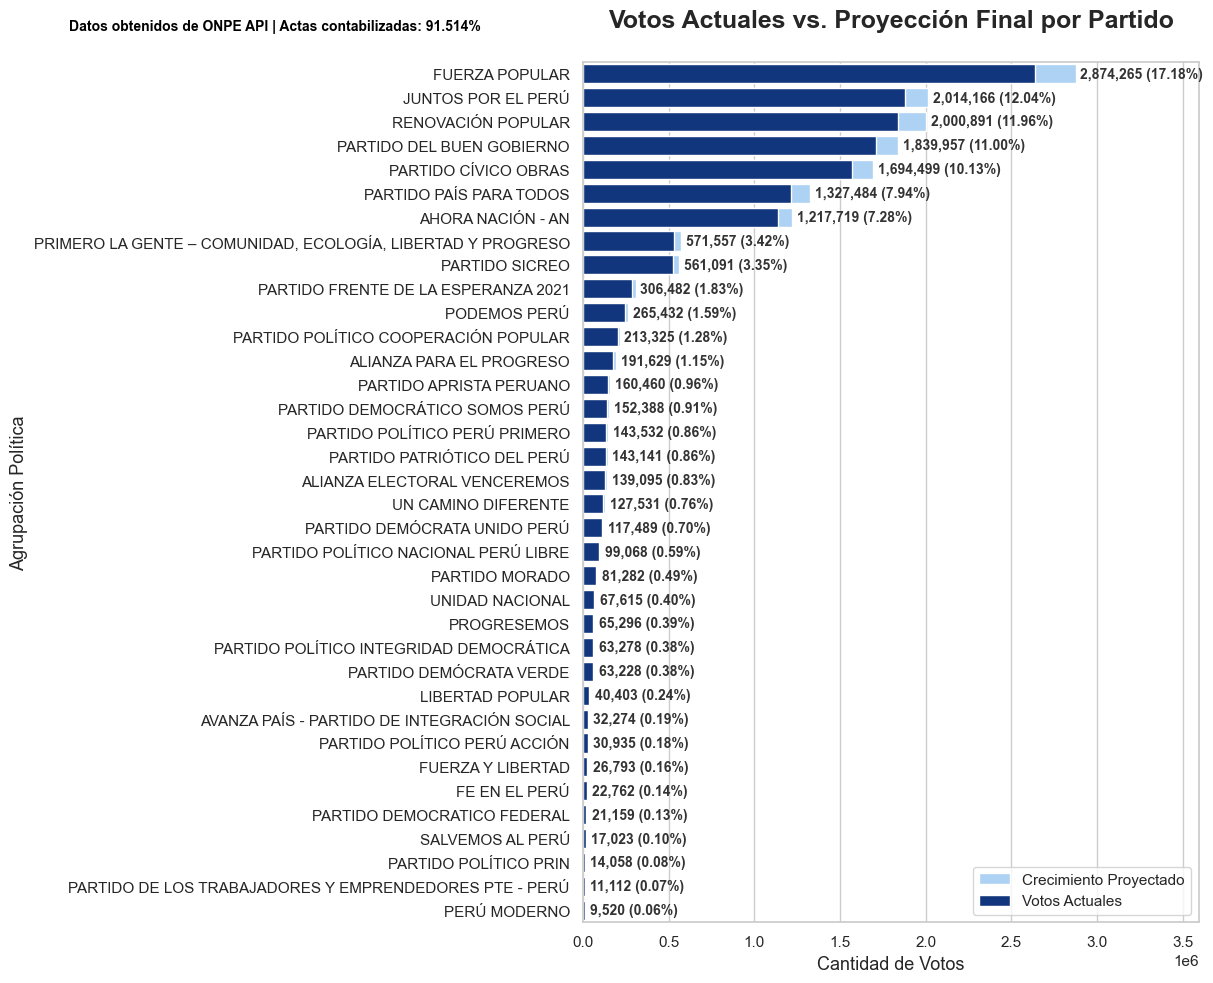